# NB_T2a · Mistral Workflows — orchestrer une petite usine

**🏗️ Build | 🚢 Ship | 📤 Share** · ⏱️ ~75 min · Mistral Workflows SDK (activités en local, sans GPU)

On imagine une **petite usine** (décor : une manufacture de lunettes du Jura, clin d'œil à **Morez**) :
recevoir une commande, s'approvisionner, fabriquer, assembler, contrôler, expédier. **Aucune
connaissance métier n'est requise** — les stations sont de simples fonctions. Ce qui nous intéresse,
c'est **comment on orchestre** cet enchaînement de façon fiable, avec **Mistral Workflows**, le moteur
d'**exécution durable** (bâti sur Temporal). Les stations viennent du module partagé
[`usine_lunettes.py`](usine_lunettes.py).

## Feuille de route
- **🏗️ Build** — modéliser l'usine en **Workflow** (orchestrateur déterministe) + **Activities**
  (le travail réel, avec retry/timeout), et **exécuter les activités en local pour de vrai**.
- **🚢 Ship** — un workflow `manufacture` : commande → appro → fabrication → [Standard | Premium] →
  contrôle (avec **reprise** et **validation humaine**), invocable par API.
- **📤 Share** — une grille de décision *Workflows vs LangGraph* (le NB_T2b refait **la même usine**
  avec un framework top-level), défendable.

**Pré-requis.** `pip install mistralai mistralai-workflows` — `MISTRAL_API_KEY` dans l'environnement.
`usine_lunettes.py` doit être à côté de ce notebook.

> **Transposition CD39.** L'usine est un prétexte : la même mécanique — un process **traçable,
> reprenable, auditable, avec validation humaine** — se transpose à un pipeline administratif
> (instruction d'un dossier, circuit de signature). On veut du **défendable**, pas un agent imprévisible.


## 📖 Glossaire (à garder sous les yeux)

| Terme | Définition courte |
|---|---|
| **Exécution durable** *(durable execution)* | Modèle où chaque étape est journalisée : après une panne, on **rejoue** le programme depuis le début, mais les étapes déjà faites ne sont **pas** ré-exécutées (leur résultat est relu dans le log). |
| **Event log** | Journal ordonné des événements du workflow. C'est la **source de vérité** qui permet le rejeu. |
| **Workflow** | Le code **orchestrateur** : il décide *quoi* lancer et *quand*. Doit être **déterministe** (rejouable à l'identique). |
| **Activity** | Une **unité de travail** à effet de bord (appel LLM, I/O, calcul). Peut échouer et être **retentée** ; son résultat est journalisé. |
| **Sandbox de déterminisme** | Contrainte sur le *corps du workflow* : pas d'horloge/hasard/I/O direct (sinon le rejeu diverge). Tout ce qui est non-déterministe va dans une **activity**. |
| **Signal / Query / Update** | Messages entrants vers un workflow en cours : `signal` (fire-and-forget, modifie l'état), `query` (lecture seule), `update` (action synchrone avec retour). |
| **`wait_for_input` / HITL** | *Human-in-the-loop* : le workflow se **suspend** (0 ressource) jusqu'à une réponse humaine — de quelques minutes à plusieurs mois. |
| **Retry policy / backoff** | Politique de reprise **déclarée** sur une activity : nb de tentatives, délai croissant (backoff exponentiel), timeouts. |
| **Métriques** | Volontairement simples : **taux de succès** (étapes OK du 1er coup), **reprises**, **coût**, **livré à temps** (oui/non). |


In [1]:
import os                    # pour lire les variables d'environnement (MISTRAL_API_KEY)
import logging              # pour couper les logs verbeux du SDK au démarrage
from datetime import timedelta   # durées déclarées sur les activités (ex. timedelta(minutes=5))
from dotenv import load_dotenv   # charge automatiquement un fichier .env si présent
load_dotenv()

# Le SDK Workflows logge sa config (Temporal/OTel) en INFO à l'import.
# On désactive ce niveau pour ne voir que nos propres prints dans le notebook.
logging.disable(logging.INFO)

CLE = os.environ.get("MISTRAL_API_KEY")      # clé API Mistral (obligatoire)
URL = os.environ.get("MISTRAL_SERVER_URL")   # URL serveur dédié (optionnel, None → cloud public)

# mistralai.workflows = le SDK Mistral Workflows
# Il expose : @wf.activity, @wf.workflow.define, wf.run_activities_locally(), wf.execute_workflow()
# Doc : https://pypi.org/project/mistralai-workflows/
import mistralai.workflows as wf

import usine_lunettes as usine              # l'usine partagée avec NB_T2b (mêmes fonctions)
from usine_lunettes import w                # helper : wrap le texte à 96 colonnes pour les prints
from usine_lunettes import enregistrer_etape  # helper : ajoute une étape à l'historique

print("Mistral Workflows SDK chargé.")
print(w(f"Usine chargée : {len(usine.COMMANDES_GOLDEN)} commandes golden, "
        f"stations = {list(usine.STATIONS)}", "•"))


Mistral Workflows SDK chargé.
• Usine chargée : 4 commandes golden, stations = ['commande', 'appro', 'fabrication',
  'finition', 'assemblage', 'controle', 'expedition']


---

## Task 1 — Pourquoi « durable » ? La chaîne naïve qui perd le fil


**Pourquoi.** *Exécution durable* est LE concept du thème — définissons-le sur un cas concret.

Une chaîne d'étapes **naïve** (des appels de fonctions à la suite) est fragile : si le processus tombe
entre la **fabrication** et le **contrôle**, l'état est **indéterminé**. Relancer depuis le début, c'est
risquer de **refabriquer** un lot déjà fait (double coût) ; reprendre au milieu, c'est ne pas savoir *où*.

L'**exécution durable** résout ça. Le moteur (Temporal, sous Mistral Workflows) tient un **event log** :
au redémarrage, il **rejoue le code du workflow depuis le début**, mais chaque activité déjà terminée
n'est **pas** ré-exécutée — son résultat est **relu dans le log**. On retrouve l'état exact d'avant la
panne, sans effet de bord dupliqué.

> **Piège.** « Rejouer » ≠ « tout refaire » : le rejeu ré-exécute la *logique d'orchestration*
> (déterministe) pour reconstruire l'état, mais **court-circuite** les activités déjà journalisées.
> D'où l'exigence de déterminisme du corps du workflow (Task 2).


In [2]:
# --- Chaîne naïve : une panne = état indéterminé -------------------------------
import random

def chaine_naive(id_commande, panne_apres="fabrication"):
    """Simule une chaîne séquentielle SANS durabilité (pour montrer sa fragilité).

    Lève une exception aléatoire (~60 %) à l'étape ``panne_apres`` : on ne sait alors pas quelles
    étapes rejouer sans risquer une double exécution.

    Parameters
    ----------
    id_commande : str
        Identifiant (affichage seulement).
    panne_apres : str, default "fabrication"
        Étape après laquelle la panne peut survenir.

    Returns
    -------
    list of str
        Étapes menées à bien si aucune panne.
    """
    faites = []
    for etape in ["commande", "appro", "fabrication", "assemblage", "controle", "expedition"]:
        if etape == panne_apres and random.random() < 0.6:   # panne worker aléatoire
            raise RuntimeError(f"PANNE worker pendant '{etape}' — étapes faites={faites}")
        faites.append(etape)
    return faites

random.seed(39)   # Jura = 39 : rend la démo reproductible
for i in range(3):
    try:
        faites = chaine_naive(f"CMD-{i:03d}")
        print(w(f"[CMD-{i:03d}] ✅ terminé : {faites}", "•"))
    except RuntimeError as e:
        print(w(f"[CMD-{i:03d}] ❌ {e}", "•"))
        print(w("     → relancer = refabriquer un lot déjà fait ? état indéterminé.", ""))


• [CMD-000] ❌ PANNE worker pendant 'fabrication' — étapes faites=['commande', 'appro']
     → relancer = refabriquer un lot déjà fait ? état indéterminé.
• [CMD-001] ❌ PANNE worker pendant 'fabrication' — étapes faites=['commande', 'appro']
     → relancer = refabriquer un lot déjà fait ? état indéterminé.
• [CMD-002] ❌ PANNE worker pendant 'fabrication' — étapes faites=['commande', 'appro']
     → relancer = refabriquer un lot déjà fait ? état indéterminé.


**Démonstration exécutable — le *replay* sans ré-exécution** (Python pur, même sémantique que
l'event log Temporal). On mémorise le résultat de chaque activité ; à la « 2ᵉ exécution » (après un
crash simulé), les activités sont **relues**, pas rappelées.

```
Code naïf              Exécution durable (Temporal / Mistral Workflows)
────────────────────   ──────────────────────────────────────────────
fabriquer()        →   Worker exécute fabriquer()
assembler()        →   Event log : « fabriquer COMPLETED, résultat={...} »
controler()            Worker exécute assembler()  … CRASH …
                       Worker redémarre → rejoue depuis le début
                       fabriquer() → résultat CONNU (log) → skip
                       reprend à assembler(), puis controler()
```


In [3]:
# L'event log = un simple dictionnaire qui mémorise chaque résultat d'activité.
# En production, Temporal le persiste sur disque ; ici, on le garde en mémoire kernel.
_event_log = {}

def activite_avec_replay(cle: str, fn):
    """Exécute fn() la 1re fois, puis relit le résultat depuis l'event log (replay).

    Paramètres
    ----------
    cle : str   — identifiant unique de l'activité (ex. "CMD-002|fabrication")
    fn  : callable — lambda ou fonction sans argument qui produit le résultat
    """
    if cle in _event_log:                           # déjà journalisé → court-circuit
        print(f"  ↻ [{cle}] relu depuis l'event log (aucun ré-appel)")
        return _event_log[cle]
    print(f"  ▶ [{cle}] exécution réelle…")
    _event_log[cle] = fn()                          # appel + journalisation du résultat
    return _event_log[cle]

c = usine.COMMANDES_GOLDEN[1]   # CMD-002, profil "reprise"

print("=== Exécution 1 (nominale) ===")
# On passe des lambdas : la fonction est appelée DANS activite_avec_replay, pas avant.
activite_avec_replay(f"{c.id}|fabrication", lambda: usine.fabriquer(c.id, c.quantite, 0, c.profil))
activite_avec_replay(f"{c.id}|assemblage",  lambda: usine.assembler(c.id, 0, c.profil))

print("\n=== Exécution 2 (simule un redémarrage après crash) ===")
# Les clés existent déjà → court-circuit exact, aucun ré-appel (c'est le rejeu Temporal).
activite_avec_replay(f"{c.id}|fabrication", lambda: usine.fabriquer(c.id, c.quantite, 0, c.profil))
activite_avec_replay(f"{c.id}|assemblage",  lambda: usine.assembler(c.id, 0, c.profil))
print("→ Les activités ne sont PAS ré-exécutées : c'est l'exécution durable. ✅")


=== Exécution 1 (nominale) ===
  ▶ [CMD-2026-002|fabrication] exécution réelle…
  ▶ [CMD-2026-002|assemblage] exécution réelle…

=== Exécution 2 (simule un redémarrage après crash) ===
  ↻ [CMD-2026-002|fabrication] relu depuis l'event log (aucun ré-appel)
  ↻ [CMD-2026-002|assemblage] relu depuis l'event log (aucun ré-appel)
→ Les activités ne sont PAS ré-exécutées : c'est l'exécution durable. ✅


---

## Task 2 — Le split Workflow / Activity (et les activités qui tournent en vrai)


**Pourquoi.** Pour que le rejeu (Task 1) soit correct, Mistral Workflows impose une **séparation
stricte** entre deux mondes :

| | **Workflow** | **Activity** |
|---|---|---|
| Rôle | Orchestrateur (quoi, quand, dans quel ordre) | Exécuteur (le travail réel) |
| I/O réseau / DB / fichiers | ❌ interdit | ✅ autorisé |
| Déterminisme (sandbox de replay) | **requis** | non requis |
| Retries / timeouts | N/A | ✅ configurables |

Le **corps du workflow** doit être **déterministe** : rejoué, il doit reproduire *exactement* la même
suite de décisions. Interdits (sinon `NonDeterministicError`) : `datetime.now()` → `wf.workflow.now()` ;
`random.random()` → `wf.workflow.random()` ; HTTP/DB/fichiers → à mettre dans une **Activity**.

> **Note honnête.** Nos stations tirent de l'aléa (défauts) : elles vivent donc **toutes** dans des
> activités, jamais dans le corps du workflow. C'est exactement la discipline attendue en production.

📖 **Doc Mistral Workflows — Activities** : <https://pypi.org/project/mistralai-workflows/>


In [4]:
# ── Définition des 3 premières activités ──────────────────────────────────────────
# @wf.activity = décorateur SDK qui enregistre la fonction comme une "Activity" Temporal.
# Conséquence : son résultat est journalisé dans l'event log → rejouable sans ré-exécution.
#
# Paramètres du décorateur :
#   name                  = identifiant stable de l'activité dans l'event log
#   start_to_close_timeout = durée max d'UNE tentative (au-delà → échec, donc retry si configuré)

@wf.activity(name="recevoir-commande", start_to_close_timeout=timedelta(seconds=30))
async def act_recevoir(id_commande: str, gamme: str, quantite: int) -> dict:
    """Valide la commande entrante. Renvoie {ok, issues}."""
    return usine.recevoir_commande(id_commande, gamme, quantite)  # délègue à l'usine

@wf.activity(name="approvisionner", start_to_close_timeout=timedelta(minutes=1))
async def act_appro(id_commande: str, gamme: str, quantite: int) -> dict:
    """Calcule la quantité à commander et le délai fournisseur. Renvoie {ok, delai_jours, cout_matiere_eur}."""
    return usine.approvisionner(id_commande, gamme, quantite)

@wf.activity(name="fabriquer", start_to_close_timeout=timedelta(minutes=2))
async def act_fabriquer(id_commande: str, quantite: int, tentative: int = 0, profil: str = "nominal") -> dict:
    """Fabrique le lot. Renvoie {ok, taux_rebut_pct, defaut}. Peut échouer (défaut aléatoire)."""
    return usine.fabriquer(id_commande, quantite, tentative, profil)


In [5]:
# ── Exécution locale réelle (pas besoin de worker Temporal) ───────────────────────
# wf.run_activities_locally() = mode SDK qui exécute les activités dans ce processus.
# En production, un worker séparé les exécuterait et l'orchestrateur Temporal les journaliserait.
c = usine.COMMANDES_GOLDEN[0]   # CMD-001 : standard, nominal (le "happy path")
with wf.run_activities_locally():
    res_rec   = await act_recevoir(c.id, c.gamme, c.quantite)   # ← vraie exécution, résultat journalisé
    res_appro = await act_appro(c.id, c.gamme, c.quantite)

print(w(f"[{c.id}] réception → {res_rec}", "✅"))
print(w(f"[{c.id}] appro     → {res_appro}", "✅"))


✅ [CMD-2026-001] réception → {'ok': True, 'issues': []}
✅ [CMD-2026-001] appro     → {'ok': True, 'moq': 300, 'extra_needed': 0, 'delai_jours': 20,
  'cout_matiere_eur': 600.0}


**À retenir.** Le workflow ne fait que **coordonner** ; l'**Activity** fait le vrai travail et
son résultat est rejouable. Ici les activités **s'exécutent réellement en local** — la même fonction
métier que dans NB_T2b, juste habillée en activité.


---

## Task 3 — Le SLA déclaratif : retries, timeouts, backoff


**Pourquoi.** La **fabrication** rate parfois (défaut réparable). Plutôt que de coder la reprise
à la main (try/except/sleep), on la **déclare** sur l'activité : c'est son *SLA*.

- **`start_to_close_timeout`** : durée max d'**une** exécution (au-delà → échec, donc retry).
- **`retry_policy_max_attempts`** : nombre de tentatives avant échec définitif.
- **`retry_policy_backoff_coefficient`** : délai **multiplié** à chaque tentative (1 s, 2 s, 4 s…).
- **`heartbeat_timeout`** : pour les activités longues, un « battement de cœur » ; son absence = worker bloqué → reprise.

> **Piège.** La retry policy est **déclarative** : en production, c'est le **moteur** qui rejoue
> l'activité, pas votre code. Ici, en local, on vérifie surtout qu'elle est bien **attachée** à l'activité.

📖 **Doc Mistral Workflows — Retry Policy** : <https://pypi.org/project/mistralai-workflows/>


In [6]:
@wf.activity(
    name="fabriquer-avec-sla",
    start_to_close_timeout=timedelta(minutes=5),   # délai max d'UNE exécution
    retry_policy_max_attempts=3,                    # 3 tentatives avant échec définitif
    retry_policy_backoff_coefficient=2.0,           # backoff exponentiel : 1s, 2s, 4s
    heartbeat_timeout=timedelta(seconds=60),        # battement de cœur (activités longues)
)
async def act_fabriquer_sla(id_commande: str, tentative: int = 0, profil: str = "nominal") -> dict:
    """Activity — fabrication, avec SLA (retries/timeout/heartbeat).

    Le profil ``reprise`` force un défaut réparable à la passe 0, corrigé à la reprise.
    """
    return usine.fabriquer(id_commande, 150, tentative, profil)

c = usine.COMMANDES_GOLDEN[1]   # profil reprise : rate à la 1re passe, OK à la reprise
with wf.run_activities_locally():
    p0 = await act_fabriquer_sla(c.id, tentative=0, profil=c.profil)
    p1 = await act_fabriquer_sla(c.id, tentative=1, profil=c.profil)
print(w(f"[{c.id}] fabrication passe 0 → {p0}", "•"))
print(w(f"[{c.id}] fabrication passe 1 (reprise) → {p1}", "•"))
print(w("La retry policy est DÉCLARÉE sur l'activité ; en production le moteur la rejoue seul.", "✅"))


• [CMD-2026-002] fabrication passe 0 → {'ok': False, 'taux_rebut_pct': 3.4, 'defaut':
  'defaut_fabrication'}
• [CMD-2026-002] fabrication passe 1 (reprise) → {'ok': True, 'taux_rebut_pct': 2.3, 'defaut':
  None}
✅ La retry policy est DÉCLARÉE sur l'activité ; en production le moteur la rejoue seul.


---

## Task 4 — Human-in-the-loop : Signal / Query / Update / wait_for_input


**Pourquoi.** Une commande peut se **bloquer en attendant un humain** : pièce manquante, exception
à arbitrer, décision « on expédie quand même ? » sur un délai trop court. Le workflow doit patienter —
parfois des semaines — **sans consommer de ressource** : il est **sérialisé sur disque** et réveillé à l'événement.

Quatre primitives (toutes réelles dans le SDK) :

| | **Signal** | **Query** | **Update** | **wait_for_input** |
|---|---|---|---|---|
| Sens | entrant, fire-and-forget | lecture seule | action + retour | invite + attente réponse |
| Modifie l'état | ✅ | ❌ | ✅ | ✅ |
| Cas usine | « pièce reçue » | « statut de la commande ? » | « corriger l'adresse » | « valider l'exception » |

- **`wait_condition(predicate, timeout)`** : suspend jusqu'à ce qu'une condition d'état (alimentée par
  des **signals**) devienne vraie.
- **`wait_for_input(prompt, timeout)`** (méthode de `wf.InteractiveWorkflow`) : suspend et **demande**
  une entrée humaine, puis reprend avec la réponse.

> **Note honnête.** On **définit et enregistre** le workflow interactif (le SDK confirme
> l'enregistrement) ; l'exécution complète d'un `wait_for_input` de bout en bout suppose un worker
> connecté à l'orchestrateur (Task 7). La *définition* est du vrai code qui se charge.

📖 **Doc Mistral Workflows — Interactive Workflows (HITL)** : <https://pypi.org/project/mistralai-workflows/>


In [7]:
# Un workflow interactif : il attend la validation humaine d'une exception.
from pydantic import BaseModel

class CommandeInput(BaseModel):
    """Entrée typée d'un workflow de commande (contrat d'API)."""
    id_commande: str
    gamme: str

@wf.workflow.define(name="exception-commande")
class ExceptionCommande(wf.InteractiveWorkflow):
    """Workflow interactif : suspend la commande jusqu'à l'arbitrage humain d'une exception.

    Illustre les primitives HITL : ``query`` (lire le statut), ``signal`` (notifier une pièce),
    ``wait_for_input`` (demander une décision oui/non).
    """

    def __init__(self):
        """Initialise l'état interne : étape courante et décision humaine (encore inconnue)."""
        super().__init__()
        self.etape = "attente_decision"
        self.decision = None

    @wf.workflow.query(name="statut")
    def statut(self) -> dict:
        """Query (lecture seule) : renvoie l'état courant sans modifier le workflow."""
        return {"etape": self.etape, "decision": self.decision}

    @wf.workflow.signal(name="piece-recue")
    async def piece_recue(self, piece: str) -> None:
        """Signal (fire-and-forget) : enregistre qu'une pièce manquante est arrivée."""
        self.etape = f"piece_recue:{piece}"

    @wf.workflow.entrypoint
    async def run(self, params: CommandeInput) -> str:
        """Point d'entrée : se suspend sur wait_for_input jusqu'à la décision humaine (≤ 30 j)."""
        reponse = await self.wait_for_input(
            prompt=f"Exception sur {params.id_commande} : accepter la dérogation ? (oui/non)",
            timeout=timedelta(days=30),
        )
        self.decision = reponse
        self.etape = "clos"
        return f"{params.id_commande} : dérogation = {reponse}"

print(w("✅ Workflow 'exception-commande' défini et enregistré (signal + query + wait_for_input).", ""))


✅ Workflow 'exception-commande' défini et enregistré (signal + query + wait_for_input).


**À retenir.** `wait_for_input()` **suspend** le run sans polling ni ressource consommée ; il
reprend quand la réponse arrive. C'est le pendant durable de l'`interrupt()` de LangGraph (NB_T2b, Task 5).


---

## Task 5 — L'usine complète : branche Standard/Premium + boucle de reprise


**Pourquoi.** La vraie usine a une **topologie**, pas une ligne droite :

- une **branche conditionnelle** : une commande **Premium** passe par une étape de **finition**
  supplémentaire ; une **Standard** va directement à l'assemblage ;
- un **cycle** : si le contrôle renvoie `rework`, on **reboucle** sur la fabrication (une reprise).

En Mistral Workflows, branche et cycle s'écrivent en **Python impératif déterministe** dans le corps du
workflow (un `if`, une boucle `for`) ; tout le travail non-déterministe reste dans les **activités**.

> **Piège.** La boucle de reprise doit **terminer** : ici le contrôle n'autorise qu'une reprise
> (`tentative_qc`), puis tranche `accept`/`scrap`. Sans garde-fou, un défaut irréparable bouclerait à l'infini.

📖 **Doc Mistral Workflows — Workflow Definition** : <https://pypi.org/project/mistralai-workflows/>


In [8]:
# ── 3 activités supplémentaires : finition, assemblage, contrôle ─────────────────
# Même patron que Task 2 : @wf.activity + start_to_close_timeout.

@wf.activity(name="finition", start_to_close_timeout=timedelta(minutes=2))
async def act_finition(id_commande: str, tentative: int) -> dict:
    """Finition Premium (polissage, gravure). Renvoie {ok, defaut}."""
    return usine.finition_premium(id_commande, tentative)

@wf.activity(name="assembler", start_to_close_timeout=timedelta(minutes=2))
async def act_assembler(id_commande: str, tentative: int) -> dict:
    """Assemblage du lot. Renvoie {ok, defaut}."""
    return usine.assembler(id_commande, tentative)

@wf.activity(name="controler", start_to_close_timeout=timedelta(minutes=1))
async def act_controle(id_commande: str, defauts: list, tentative_qc: int) -> dict:
    """Contrôle qualité. Renvoie {verdict: accept | rework | scrap}."""
    return usine.controler_qualite(id_commande, defauts, tentative_qc)


In [9]:
# ── Le Workflow orchestrateur ────────────────────────────────────────────────────
# @wf.workflow.define = enregistre la classe comme un "Workflow" Temporal.
# execution_timeout = durée max totale de l'instance (inclut les pauses HITL).
# Le corps de run() est DÉTERMINISTE : pas d'I/O, pas d'aléa.
# Tout le travail réel (avec aléa/I/O) est délégué aux activités via `await act_*()`.

@wf.workflow.define(name="manufacture", execution_timeout=timedelta(hours=2))
class Manufacture:

    @wf.workflow.entrypoint              # ← point d'entrée appelé par wf.execute_workflow()
    async def run(self, params: CommandeInput) -> dict:
        cid, gamme = params.id_commande, params.gamme

        await act_recevoir(cid, gamme, 150)    # étape 1 — validation
        await act_appro(cid, gamme, 150)       # étape 2 — appro (journalisée, rejouable)

        defauts, verdict = [], "rework"
        for tentative in range(2):             # 1 passe + 1 reprise max (garde-fou de terminaison)
            fab = await act_fabriquer(cid, 150, tentative)
            d = [fab["defaut"]]                # collecte les défauts de cette passe

            if gamme == "premium":             # ← BRANCHE déterministe : Standard/Premium
                fin = await act_finition(cid, tentative)
                d.append(fin["defaut"])

            asm = await act_assembler(cid, tentative)
            d.append(asm["defaut"])
            defauts = [x for x in d if x]     # filtre les None (= étapes sans défaut)

            qc = await act_controle(cid, defauts, tentative)
            verdict = qc["verdict"]
            if verdict in ("accept", "scrap"): # ← SORTIE du CYCLE : rework = reboucle
                break

        return {"commande": cid, "verdict": verdict, "defauts": defauts}

print(w("✅ Workflow 'manufacture' défini (branche Standard/Premium + boucle de reprise).", ""))


✅ Workflow 'manufacture' défini (branche Standard/Premium + boucle de reprise).


---

## Task 6 — Durable Agent : un LLM dans le workflow


**Pourquoi.** Un **superviseur d'usine** peut être un agent LLM (planifier, arbitrer une
disposition en langage naturel). Placé dans un workflow durable, s'il tombe en plein raisonnement, il
**reprend exactement** où il en était : chaque appel LLM et chaque appel d'outil est une **activité
journalisée**. C'est la promesse du *Durable Agent*. Nécessite le plugin `mistralai-workflows-plugins-mistralai`.

📖 **Doc Mistral Workflows — Durable Agents** : <https://pypi.org/project/mistralai-workflows/>


In [10]:
try:
    import mistralai.workflows.plugins.mistralai as wf_mistral
    HAS_PLUGIN = True
except Exception:
    HAS_PLUGIN = False   # plugin agents optionnel

if HAS_PLUGIN:
    superviseur = wf_mistral.Agent(
        model="mistral-medium-latest",
        name="superviseur-usine",
        instructions=("Tu es superviseur de l'usine. Tu arbitres les exceptions et priorises "
                      "les commandes urgentes."),
    )
    print(w("✅ Durable Agent 'superviseur-usine' défini (LLM + tools dans un workflow).", ""))
else:
    print(w("ℹ️ Plugin agents non installé — on montre le schéma, on ne l'exécute pas ici. "
            "En prod : Runner.run(agent, messages) enveloppe la boucle LLM en activités durables.", ""))


ℹ️ Plugin agents non installé — on montre le schéma, on ne l'exécute pas ici. En prod :
Runner.run(agent, messages) enveloppe la boucle LLM en activités durables.


---

## Task 7 — Lancer, et mesurer


**Pourquoi.** L'orchestration **complète** d'un workflow (`wf.execute_workflow`) requiert un
**worker** connecté à l'orchestrateur Temporal (hébergé Mistral / preview). On **tente** l'appel (et on
l'explique s'il n'est pas branché), puis on exécute la chaîne **via les activités en local** pour
produire de **vraies métriques** sur les commandes golden :

- **taux de succès** — part d'étapes réussies du premier coup ;
- **reprises** — combien de fois la commande est repassée en fabrication ;
- **coût** — somme des coûts d'étapes ;
- **livré à temps** — délai ≤ échéance (oui/non).

📖 **Doc Mistral Workflows — Run Locally** : <https://pypi.org/project/mistralai-workflows/>


In [11]:
# 1) Tentative d'orchestration complète (nécessite un worker/Temporal déployé) -----
try:
    h = await wf.execute_workflow(
        Manufacture,
        CommandeInput(id_commande="CMD-2026-001", gamme="standard"),
        wait=True,
    )
    print(w(f"✅ execute_workflow → {h}", ""))
except Exception as e:
    # Honnête : sans worker/orchestrateur branché, on l'explique — les activités, elles, tournent en local.
    print(w(f"ℹ️ execute_workflow indisponible ici (worker/Temporal non branché) : "
            f"{type(e).__name__}. Les activités, elles, tournent en local ci-dessous.", ""))


✅ execute_workflow → {'commande': 'CMD-2026-001', 'verdict': 'accept', 'defauts': []}


In [12]:
# 2) Exécution locale sur les 4 commandes golden — produit les métriques + le parcours ──
# piloter() reproduit la logique de Manufacture.run() hors du moteur Temporal,
# pour alimenter les visualisations de Task 8 (métriques, trajectoire, Gantt, entonnoir).
async def piloter(c):
    hist    = []        # historique des étapes : alimenté par enregistrer_etape()
    defauts = []        # défauts de la passe courante
    verdict = "rework"  # valeur initiale (sera écrasée dès le 1er contrôle)
    a_temps = None      # None = commande non expédiée (scrap)

    # ── Étapes initiales (hors boucle) ─────────────────────────────────────────
    enregistrer_etape(hist, "commande", usine.recevoir_commande(c.id, c.gamme, c.quantite))
    ap = usine.approvisionner(c.id, c.gamme, c.quantite)
    enregistrer_etape(hist, "appro", ap)
    hitl = ap["delai_jours"] > c.echeance_jours   # délai fournisseur > échéance → HITL

    # ── Boucle fabrication → contrôle (1 passe + 1 reprise max) ───────────────
    for tentative in range(2):
        fab = await act_fabriquer(c.id, c.quantite, tentative, c.profil)
        enregistrer_etape(hist, "fabrication", fab)
        d = [fab["defaut"]]                        # défauts de cette passe

        if c.gamme == "premium":                   # branche : Premium passe par la finition
            fin = await act_finition(c.id, tentative)
            enregistrer_etape(hist, "finition", fin)
            d.append(fin["defaut"])

        asm = await act_assembler(c.id, tentative)
        enregistrer_etape(hist, "assemblage", asm)
        d.append(asm["defaut"])

        defauts = [x for x in d if x]             # filtre les None (étapes sans défaut)
        qc = await act_controle(c.id, defauts, tentative)
        enregistrer_etape(hist, "controle", {"ok": qc["verdict"] == "accept"})
        verdict = qc["verdict"]
        if verdict in ("accept", "scrap"):         # sortie du cycle (rework = reboucle)
            break

    # ── Expédition (seulement si accepté) ──────────────────────────────────────
    if verdict == "accept":
        exp = usine.expedier(c.id, c.quantite, ap["delai_jours"], c.echeance_jours)
        enregistrer_etape(hist, "expedition", exp)
        a_temps = exp["livre_a_temps"]

    return {
        "id": c.id, "gamme": c.gamme, "verdict": verdict,
        "reprises": tentative, "hitl": hitl, "a_temps": a_temps,
        "defauts": defauts,
        "parcours": hist,                          # liste d'étapes pour les vues Task 8
        "kpis": usine.calcul_metriques(hist, c.quantite),
    }


In [13]:
# ── Lancement sur les 4 commandes golden + affichage des résultats ───────────────
with wf.run_activities_locally():
    resultats = [await piloter(c) for c in usine.COMMANDES_GOLDEN]

for r in resultats:
    flag  = "✅" if r["verdict"] == "accept" else "❌"
    notes = f"reprises={r['reprises']}"
    if r["hitl"]:          notes += " ⏸HITL"
    if r["a_temps"] is False: notes += " ⏰retard"
    k = r["kpis"]
    print(w(f"{r['id']:14} [{r['gamme']:8}] {r['verdict']:7} {notes} "
            f"succès={k['taux_succes']} coût={k['cout_eur']}€ defauts={r['defauts']}", flag))

ok = sum(1 for r in resultats if r["verdict"] == "accept")
print(w(f"Bilan : {ok}/{len(resultats)} commandes acceptées.", "📊"))


✅ CMD-2026-001   [standard] accept  reprises=0 succès=1.0 coût=5.6€ defauts=[]
✅ CMD-2026-002   [premium ] accept  reprises=1 succès=0.818 coût=11.0€ defauts=[]
❌ CMD-2026-003   [premium ] scrap   reprises=0 ⏸HITL succès=0.667 coût=6.4€
  defauts=['piece_cassee']
✅ CMD-2026-004   [standard] accept  reprises=0 ⏸HITL ⏰retard succès=0.833 coût=5.6€ defauts=[]
📊 Bilan : 3/4 commandes acceptées.


---

## Task 8 — Visualiser l'usine


**Pourquoi.** Un pipeline se pilote mieux quand on le *voit*. Six vues complémentaires,
toutes importées de [`usine_viz.py`](usine_viz.py) (style aligné sur les notebooks J2) :

1. **Topologie** — le graphe du workflow (branche Standard/Premium, boucle de reprise en pointillé rouge).
2. **Trajectoires** — le chemin réel de chaque commande (points vert/rouge par étape, reprises visibles).
3. **Métriques** — taux de succès par commande (verdict, nombre de reprises, retard).
4. **Coûts** — décomposition du coût par station (barres empilées).
5. **Gantt** — durée de chaque étape par commande (reprises = répétition de station sur la même ligne).
6. **Entonnoir qualité** — combien de commandes passent chaque étape sans défaut (goulot d'étranglement).


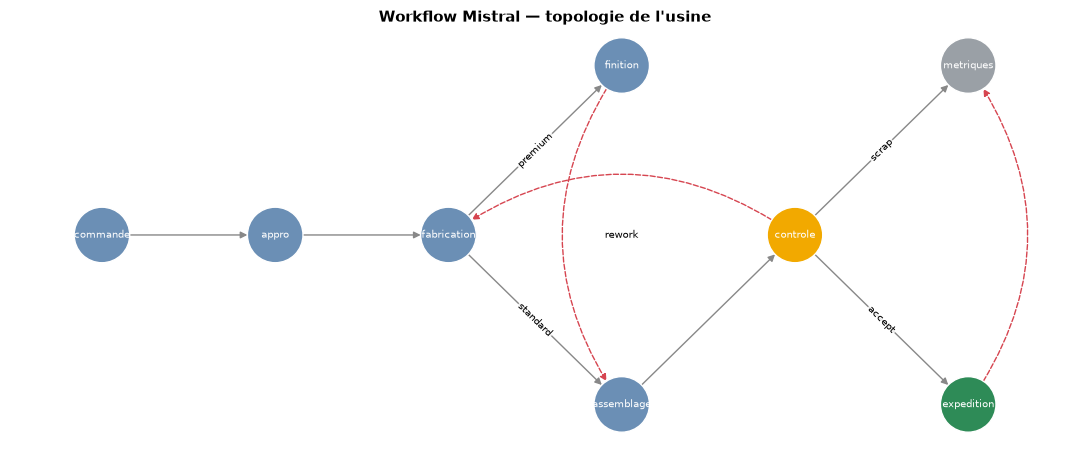

In [14]:
import matplotlib.pyplot as plt
import usine_viz as viz

# Topologie du workflow Mistral : le SCHÉMA des étapes + branche (Standard/Premium) + reprise (rouge pointillé).
# (NB_T2b, lui, extraira le VRAI graphe de LangGraph.)
edges = [("commande", "appro"), ("appro", "fabrication"),
         ("fabrication", "finition", "premium"), ("fabrication", "assemblage", "standard"),
         ("finition", "assemblage"), ("assemblage", "controle"),
         ("controle", "expedition", "accept"), ("controle", "fabrication", "rework"),
         ("controle", "metriques", "scrap"), ("expedition", "metriques")]
viz.dessiner_topologie(edges, "Workflow Mistral — topologie de l'usine", source="commande",
                       couleurs_noeuds={"controle": viz.ORANGE, "expedition": viz.VERT, "metriques": viz.GRIS})
plt.show()


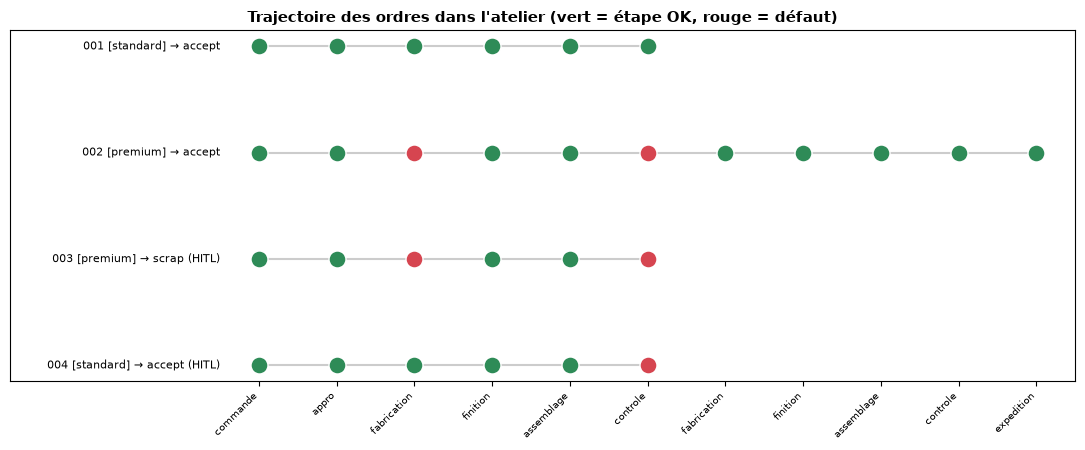

In [15]:
# Trajectoire de chaque commande (la reprise de CMD-002 se lit directement : la chaîne est plus longue)
viz.dessiner_trajectoires(resultats)
plt.show()


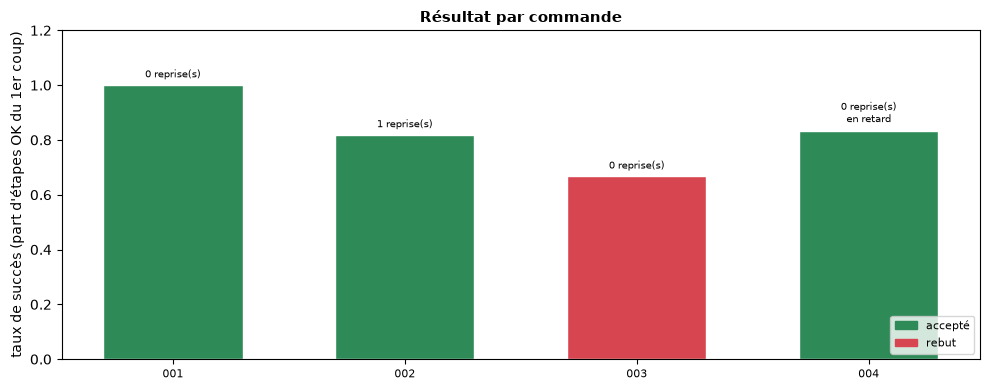

In [16]:
# Résultat par commande (taux de succès, verdict, reprises, retard)
viz.dessiner_kpis(resultats)
plt.show()


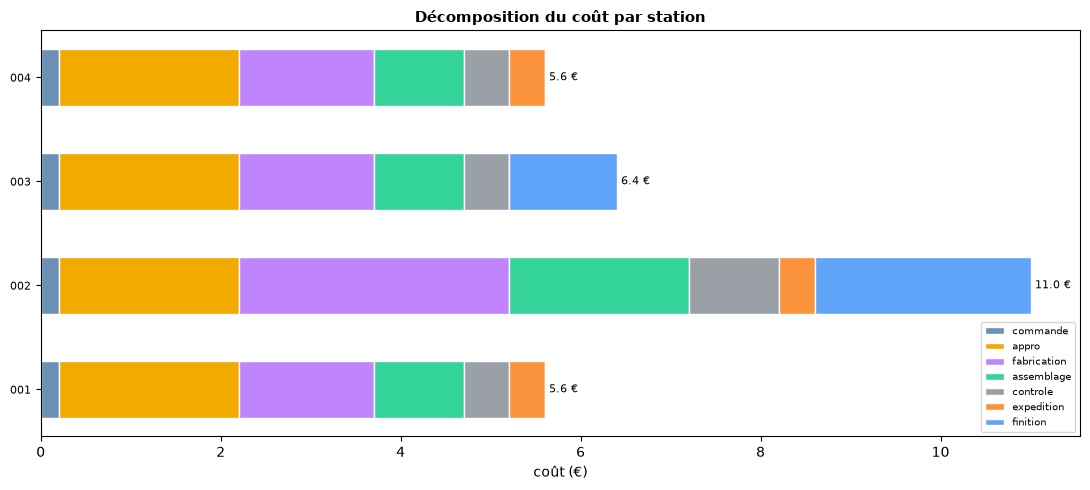

In [17]:
# Décomposition du coût par station (barres empilées — où part l'argent ?)
viz.dessiner_couts(resultats)
plt.show()


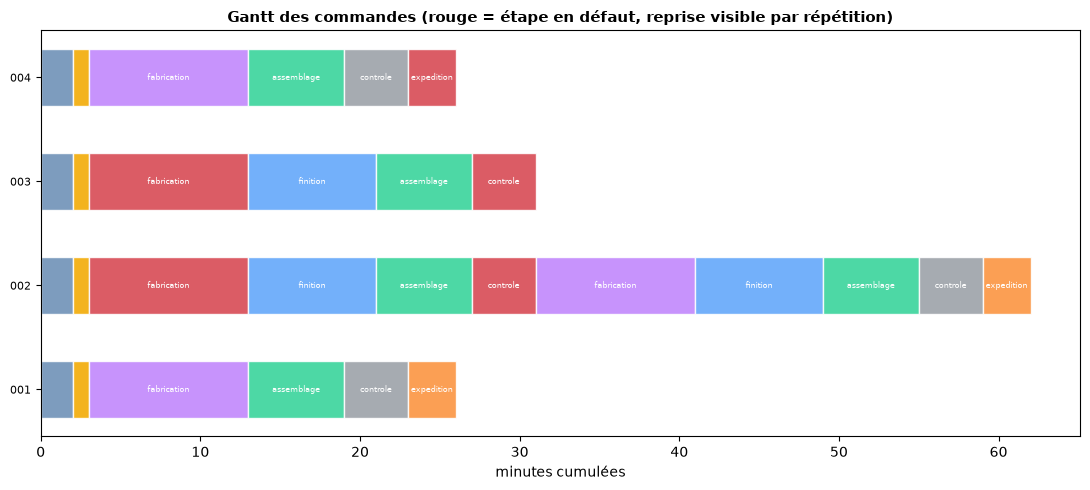

In [18]:
# Gantt des commandes (durée de chaque étape ; reprise = station répétée sur la même ligne)
viz.dessiner_gantt(resultats)
plt.show()


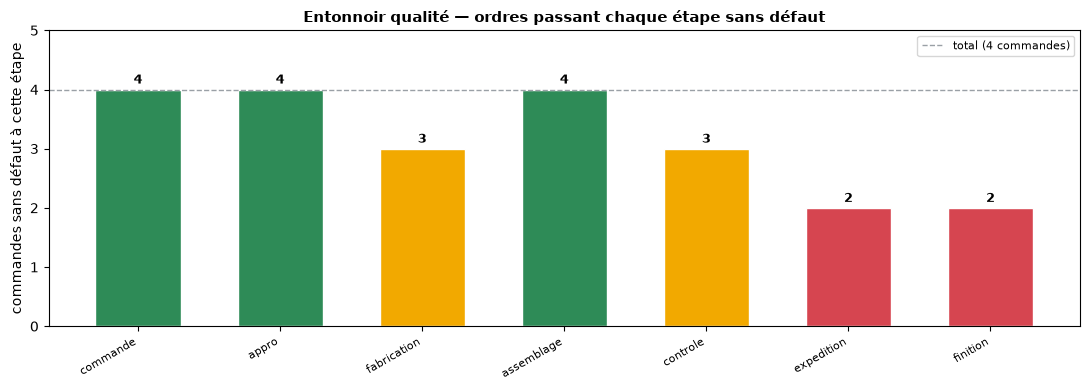

In [19]:
# Entonnoir qualité (combien d'ordres passent chaque étape sans défaut → goulot visible)
viz.dessiner_entonnoir(resultats)
plt.show()


---

## 🔧 Activité — votre code ici


**But.** Ajouter une station **emballage cadeau** (option Premium) à l'usine.

1. Écrire une activité `act_emballage` (nom `emballage`, `start_to_close_timeout=1 min`,
   `retry_policy_max_attempts=2`) renvoyant `{"ok": bool, "defaut": str | None}`.
2. L'insérer dans `Manufacture.run` **après l'assemblage**, uniquement pour la gamme Premium.
3. Faire remonter son défaut éventuel dans la liste `defauts` transmise au contrôle.


In [20]:
# 👉 À vous.
# @wf.activity(name="emballage", start_to_close_timeout=timedelta(minutes=1),
#              retry_policy_max_attempts=2)
# async def act_emballage(id_commande: str, tentative: int = 0) -> dict:
#     ...  # simuler un défaut d'emballage éventuel
#
# TODO : réécrire un ManufactureV2 qui insère act_emballage après act_assembler (si premium).
print("Squelette prêt — implémenter act_emballage et l'insérer dans le workflow.")


Squelette prêt — implémenter act_emballage et l'insérer dans le workflow.


### 🧭 Ce qu'on a construit vs la production

| Brique de ce notebook | Équivalent production |
|---|---|
| Activités exécutées en local (`run_activities_locally`) | Workers déployés (K8s/Helm) connectés à l'orchestrateur Mistral |
| `execute_workflow` tenté puis expliqué | Orchestrateur Temporal hébergé (preview) + workers dans votre VPC |
| Défauts simulés (seedés) | Remontées réelles des postes / capteurs |
| `wait_for_input` en démo | Validation via Le Chat / webhook / UI métier (jusqu'à des mois) |
| Métriques calculées a posteriori | Observabilité OTel + dashboards Studio en temps réel |

### 🚀 Pour aller plus loin
- **NB_T2b** — *la même usine* en **LangChain/LangGraph** : `StateGraph`, branche, cycle, `interrupt`,
  exécuté **en live** sur des modèles Mistral. C'est là qu'on compare honnêtement les deux moteurs.
- **À vous.** Ajouter un `schedule` (cron) pour lancer l'usine chaque matin, et un `signal`
  « commande prioritaire » qui réordonne la file.


---

### 📚 Pour aller plus loin

- **Temporal — « The definitive guide to Durable Execution »** : temporal.io/blog/what-is-durable-execution — le modèle event-sourcing / replay dont s'inspire Mistral Workflows.- **« Benchmarking Agentic Workflow Generation »** (2024) arXiv:2410.07869 : évaluation des capacités workflow des LLMs.- **Mistral Workflows** — pypi.org/project/mistralai-workflows/ : le SDK, sa doc publique n'étant pas référencée (activity, signal, wait_for_input).
> 🗂️ Références complètes de la formation :
> [`ressources/references_academiques.md`](../../ressources/references_academiques.md).
